In [10]:
import numpy as np
import os
import pandas as pd
import xarray as xr
from glob import glob
import matplotlib.pyplot as plt
import itertools as it
from scipy.stats import linregress
from matplotlib.cm import get_cmap
from utils.constants import chamber_levels_complete
import matplotlib.ticker as ticker
import itertools as it
from matplotlib import rcParams
from matplotlib.colors import BoundaryNorm


rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 14

prefix_default = '20231113'
prefix_uptake = '20240311'
prefix_list = [prefix_default, prefix_uptake] # , '20240316_2']

pft_names = ['Spruce', 'Tamarack', 'Shrub']

outdir = os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 'extract')

chambers_ordered = {
    'amb': ['6', '20', '13', '8', '17'], 
    'elev': ['19', '11', '4', '16', '10']
}

def fit_line(x, y):
    filt = ~np.isnan(x) & ~np.isnan(y)
    x = x[filt]
    y = y[filt]

    if sum(filt) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    res = linregress(x, y)
    xnew = np.linspace(x.min(), x.max(), 3)
    ynew = res.slope * xnew + res.intercept
    r2 = res.rvalue**2  # coefficient of determination
    return xnew, ynew, res.slope, res.intercept, r2

# Read the data from `extract_ts_genvars.py`

Generate a growing season time series and an annual collection

In [13]:
collection_gs = {}
collection_annual = {}

for prefix in prefix_list:
    temp_data = pd.read_csv(os.path.join(outdir, prefix, 'analysis_ts.csv'),
                                         header = [0, 1, 2, 3], index_col = 0, parse_dates=True)

    # restrict BTRAN & ZWT to growing season
    for col in temp_data.columns:
        if col[1] in ['BTRAN','ZWT']:
            temp_data.loc[(temp_data.index.month < 5) | (temp_data.index.month > 10), col] = np.nan

    # ratio of total nutrient uptake to AVAILC

    # average hummock and hollow, resample to annual
    temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
        ).apply(lambda df: df.iloc[:,0] * 0.64 + df.iloc[:,1] * 0.36)

    filt = (temp_data.index.month >= 5) & (temp_data.index.month <= 10)
    # Limit to < 2021 to be consistent with Paul's data
    filt = filt & (temp_data.index.year <= 2021)
    collection_gs[prefix] = temp_data.loc[filt, :]

    temp_annual = temp_data.resample('1Y').mean()
    temp_annual.index = temp_annual.index.year
    temp_annual.columns = temp_annual.columns.reorder_levels(['variable', 'pft', 'plot'])
    temp_annual = temp_annual.stack()
    collection_annual[prefix] = temp_data

/tmp/ipykernel_1781951/2507431722.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
/tmp/ipykernel_1781951/2507431722.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1


In [3]:
# Water limitation
# Skip

"""diff = collection_gs[prefix_uptake] - collection_gs[prefix_default]

fig, axes = plt.subplots(3, 3, figsize = (15, 10), sharex = True)
plot = '10'
zwt = diff.loc[:, (plot, 'ZWT', '0')]
tbot = diff.loc[:, (plot, 'TBOT', '0')]
for i, pft in enumerate(['2','3','11']):
    # BTRAN
    ax = axes[i, 0]
    cpool = collection_gs[prefix_default].loc[:, (plot, 'BTRAN', pft)]
    h = ax.plot(cpool.index, cpool, color = 'r', label = 'Default')
    cpool = collection_gs[prefix_uptake].loc[:, (plot, 'BTRAN', pft)]
    h = ax.plot(cpool.index, cpool, color = 'b', label = 'V1')
    ax.set_title('$\Delta$ BTRAN')
    ax.grid(True)
    plt.setp(ax.get_xticklabels(), rotation = 90)
    if i == 0:
        ax.legend()

    # water table depth
    ax = axes[i, 1]
    cpool = collection_gs[prefix_default].loc[:, (plot, 'ZWT', '0')]
    h = ax.plot(cpool.index, cpool, color = 'r')
    cpool = collection_gs[prefix_uptake].loc[:, (plot, 'ZWT', '0')]
    h = ax.plot(cpool.index, cpool, color = 'b')
    ax.set_title('Water Table Depth (m)')
    ax.grid(True)
    plt.setp(ax.get_xticklabels(), rotation = 90)

    # soil moisture
    ax = axes[i, 2]
    cpool = collection_gs[prefix_default].loc[:, (plot, 'H2OSOI_ROOTFR', pft)]
    h = ax.plot(cpool.index, cpool, color = 'r')
    cpool = collection_gs[prefix_uptake].loc[:, (plot, 'H2OSOI_ROOTFR', pft)]
    h = ax.plot(cpool.index, cpool, color = 'b')
    ax.set_title('Soil water (m3 m-3)')
    ax.grid(True)
    plt.setp(ax.get_xticklabels(), rotation = 90) """

"diff = collection_gs[prefix_uptake] - collection_gs[prefix_default]\n\nfig, axes = plt.subplots(3, 3, figsize = (15, 10), sharex = True)\nplot = '10'\nzwt = diff.loc[:, (plot, 'ZWT', '0')]\ntbot = diff.loc[:, (plot, 'TBOT', '0')]\nfor i, pft in enumerate(['2','3','11']):\n    # BTRAN\n    ax = axes[i, 0]\n    cpool = collection_gs[prefix_default].loc[:, (plot, 'BTRAN', pft)]\n    h = ax.plot(cpool.index, cpool, color = 'r', label = 'Default')\n    cpool = collection_gs[prefix_uptake].loc[:, (plot, 'BTRAN', pft)]\n    h = ax.plot(cpool.index, cpool, color = 'b', label = 'V1')\n    ax.set_title('$\\Delta$ BTRAN')\n    ax.grid(True)\n    plt.setp(ax.get_xticklabels(), rotation = 90)\n    if i == 0:\n        ax.legend()\n\n    # water table depth\n    ax = axes[i, 1]\n    cpool = collection_gs[prefix_default].loc[:, (plot, 'ZWT', '0')]\n    h = ax.plot(cpool.index, cpool, color = 'r')\n    cpool = collection_gs[prefix_uptake].loc[:, (plot, 'ZWT', '0')]\n    h = ax.plot(cpool.index, cpool,

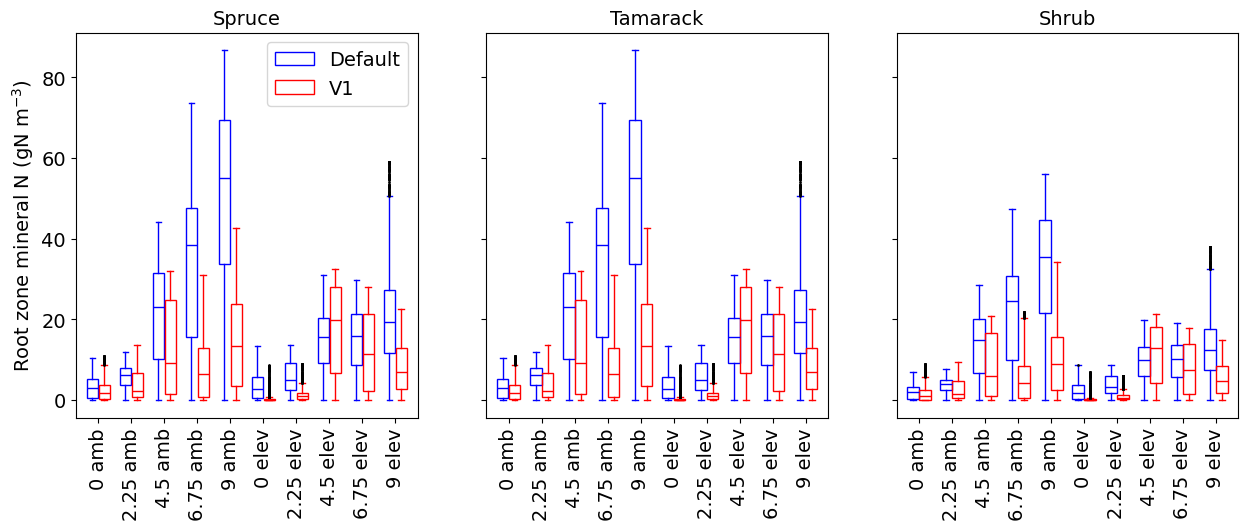

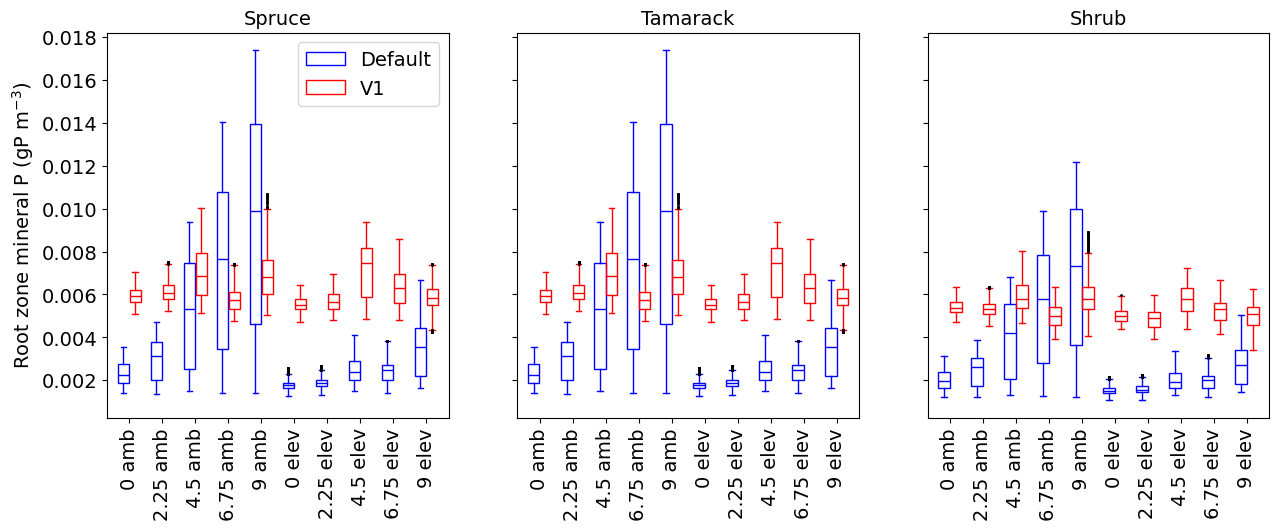

In [4]:
# Column nutrient level

xticklabels = ['0 amb', '2.25 amb','4.5 amb', '6.75 amb', '9 amb', 
               '0 elev', '2.25 elev', '4.5 elev', '6.75 elev', '9 elev']

for nu in ['N','P']:
    if nu == 'N':
        nu_var = 'SMINN_vr_ROOTFR'
    else:
        nu_var = 'SOLUTIONP_vr_ROOTFR'

    fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = True)
    for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
        ax = axes.flat[i]

        prefix = prefix_default
        temp = collection_gs[prefix].loc[:, (slice(None), nu_var, pft)
            ].loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
        temp.columns = temp.columns.get_level_values(0)
        bp1 = ax.boxplot(temp, positions = np.arange(temp.shape[1]) - 0.18, widths = 0.35,
                         patch_artist = True, flierprops = {'markersize': 1})

        prefix = prefix_uptake
        temp = collection_gs[prefix].loc[:, (slice(None), nu_var, pft)
            ].loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
        temp.columns = temp.columns.get_level_values(0)
        bp2 = ax.boxplot(temp, positions = np.arange(temp.shape[1]) + 0.18, widths = 0.35, 
                         patch_artist = True, flierprops = {'markersize': 1})

        for element in ['boxes', 'whiskers', 'fliers', 'means', 'medians', 'caps']:
            plt.setp(bp1[element], color='b')
            plt.setp(bp2[element], color='r')
        for patch in bp1['boxes']:
            patch.set_facecolor('none')
        for patch in bp2['boxes']:
            patch.set_facecolor('none')

        if i == 0:
            ax.set_ylabel(f'Root zone mineral {nu} (g{nu}' + ' m$^{-3}$)')
            ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ['Default', 'V1'], loc='upper right')

        #if nu == 'N':
        #    ax.set_ylim([0, 20])
        #else:
        #    ax.set_ylim([0, 0.006])

        ax.set_xticks(np.arange(temp.shape[1]))
        ax.set_xticklabels(xticklabels, rotation = 90)
        ax.set_xlabel(None)
        ax.set_title(name)

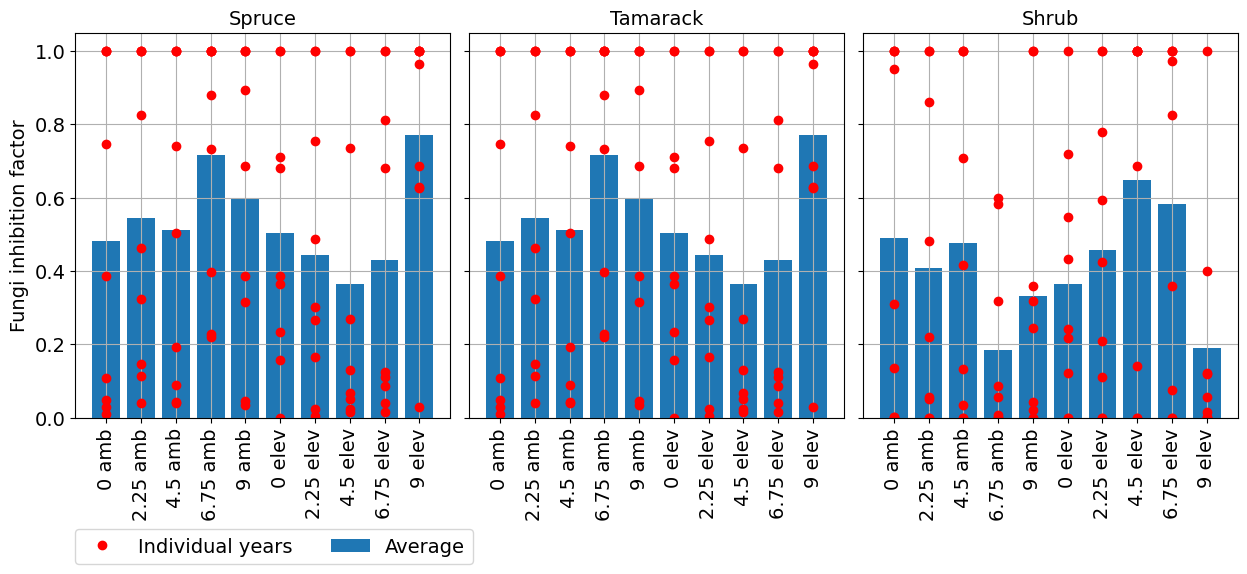

In [5]:
# Fungi inhibition on nutrient uptake

xticklabels = ['0 amb', '2.25 amb','4.5 amb', '6.75 amb', '9 amb', 
               '0 elev', '2.25 elev', '4.5 elev', '6.75 elev', '9 elev']
prefix = prefix_uptake

fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = True)
fig.subplots_adjust(wspace = 0.05)
for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
    ax = axes.flat[i]

    temp = collection_gs[prefix].loc[:, (slice(None), 'FUNGI_INHIB_PATCH', pft)
        ].resample('1Y').mean().loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
    temp.columns = temp.columns.get_level_values(0)
    plotID = np.broadcast_to(np.arange(temp.shape[1]).reshape(1, -1), temp.shape)
    h, = ax.plot(plotID.reshape(-1), temp.values.reshape(-1), 'or')
    h2 = ax.bar(plotID[0, :], np.mean(temp, axis = 0))

    if i == 0:
        ax.set_ylabel('Fungi inhibition factor')
        ax.legend([h, h2], ['Individual years', 'Average'], ncol = 2, loc = [0, -0.38])

    ax.set_xticks(np.arange(temp.shape[1]))
    ax.set_xticklabels(xticklabels, rotation = 90)
    ax.set_xlabel(None)
    ax.set_title(name)
    ax.grid(True)

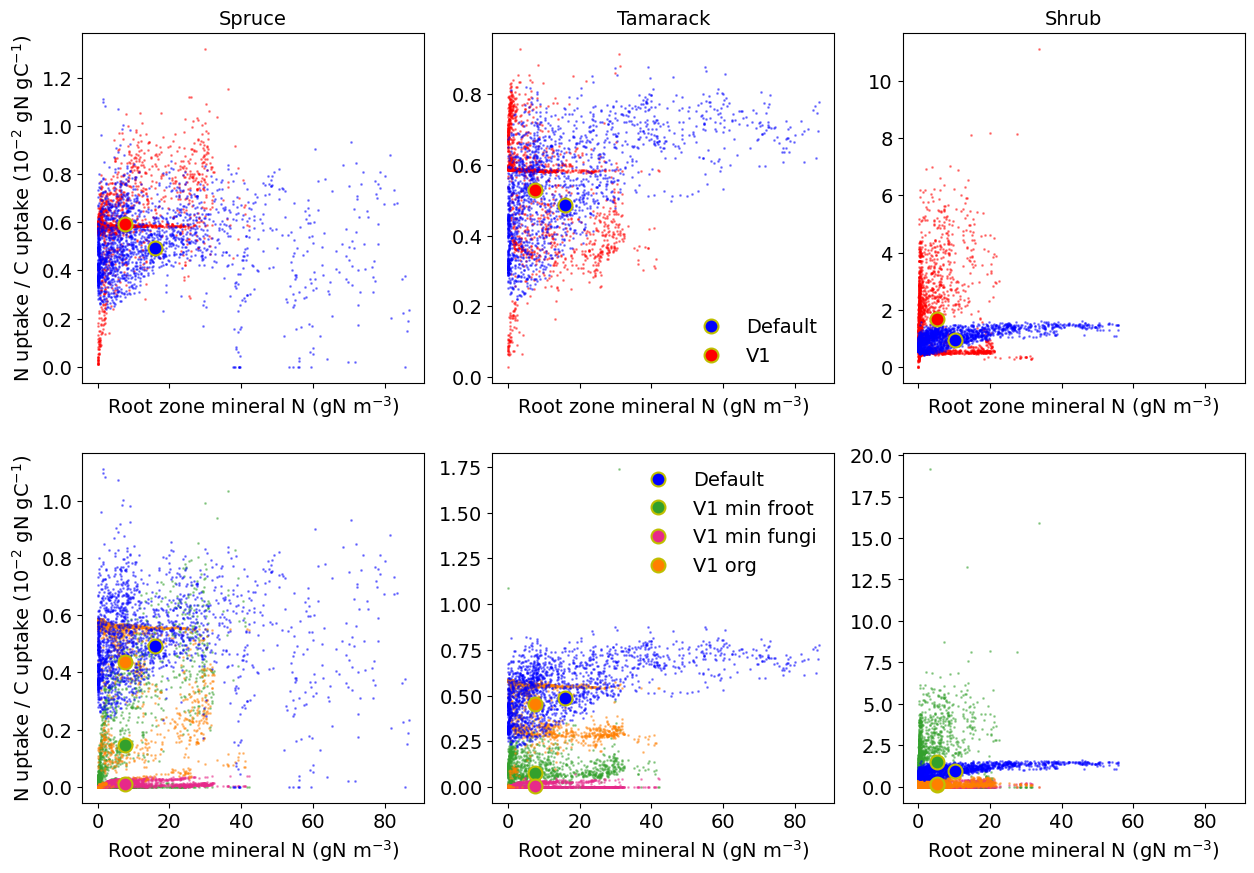

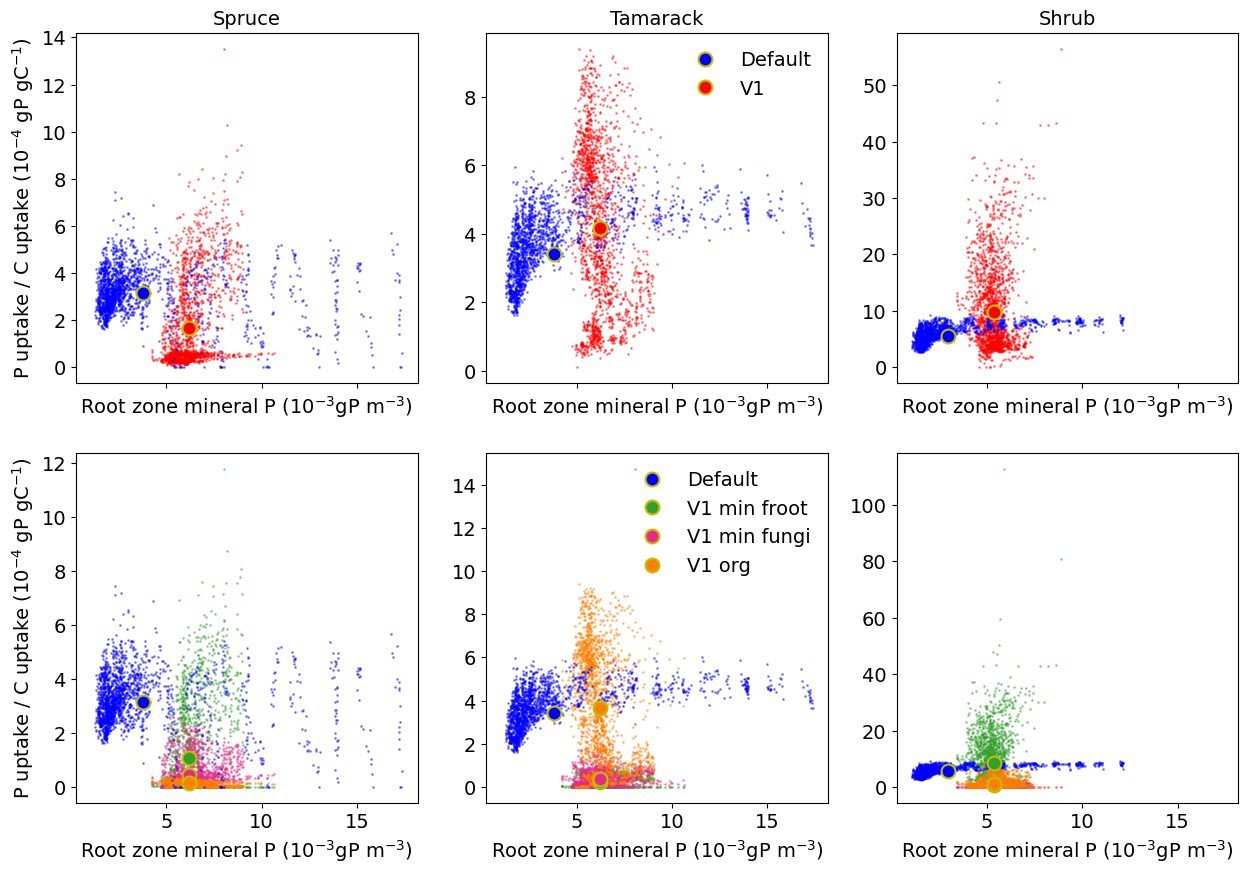

In [6]:
# Mineral + organic nutrient uptake/C assimilation
for nu in ['N','P']:
    if nu == 'N':
        nu_var = 'SMINN_vr_ROOTFR'
    else:
        nu_var = 'SOLUTIONP_vr_ROOTFR'

    fig, axes = plt.subplots(2, 3, figsize = (15, 10), sharex = True, sharey = False)
    for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
        for j in range(2):
            ax = axes[j, i]
            for prefix, pname, colr in zip(prefix_list, ['Default', 'V1'], ['b','r']):
                sminn = collection_gs[prefix].loc[:, (slice(None), nu_var, pft)]
                sminn = sminn.resample('10D').mean()
                sminn_mean = sminn.mean().mean()

                cdemand = collection_gs[prefix].loc[:, (slice(None), 'AVAILC', pft)]

                smin_uptake = collection_gs[prefix].loc[:, (slice(None), 
                                                            f'SMIN{nu}_TO_{nu}POOL', pft)]
                min_cpool = smin_uptake.resample('10D').mean() / \
                    cdemand.resample('10D').mean().values
                min_cpool_mean = smin_uptake.mean().mean() / cdemand.mean().mean()
                if nu == 'N':
                    min_cpool = min_cpool * 1e2
                    min_cpool_mean = min_cpool_mean * 1e2
                elif nu == 'P':
                    sminn = sminn * 1e3
                    sminn_mean = sminn_mean * 1e3
                    min_cpool = min_cpool * 1e4
                    min_cpool_mean = min_cpool_mean * 1e4

                if pname == 'V1':
                    min_uptake_root = collection_gs[prefix].loc[:, (slice(None), 
                        f'FROOT_{nu}DEMAND_POT', pft)] / collection_gs[prefix].loc[:, 
                        (slice(None), f'PLANT_{nu}DEMAND_POT', pft)].values * smin_uptake.values
                    min_uptake_fungi = collection_gs[prefix].loc[:, (slice(None), 
                        f'FUNGI_{nu}DEMAND_POT', pft)] / collection_gs[prefix].loc[:, 
                        (slice(None), f'PLANT_{nu}DEMAND_POT', pft)].values * smin_uptake.values
                    min_cpool_root = min_uptake_root.resample('10D').mean() / \
                    cdemand.resample('10D').mean().values
                    min_cpool_fungi = min_uptake_fungi.resample('10D').mean() / \
                    cdemand.resample('10D').mean().values
                    min_cpool_root_mean = min_uptake_root.mean().mean() / cdemand.mean().mean()
                    min_cpool_fungi_mean = min_uptake_fungi.mean().mean() / cdemand.mean().mean()
                    if nu == 'N':
                        min_cpool_root = min_cpool_root * 1e2
                        min_cpool_fungi = min_cpool_fungi * 1e2
                        min_cpool_fungi_mean = min_cpool_fungi_mean * 1e2
                        min_cpool_root_mean = min_cpool_root_mean * 1e2
                    elif nu == 'P':
                        min_cpool_root = min_cpool_root * 1e4
                        min_cpool_fungi = min_cpool_fungi * 1e4
                        min_cpool_fungi_mean = min_cpool_fungi_mean * 1e4
                        min_cpool_root_mean = min_cpool_root_mean * 1e4

                    sorg_uptake = collection_gs[prefix].loc[:, \
                        (slice(None), f'FUNGI_SOM_TO_{nu}POOL', pft)]
                    org_cpool = sorg_uptake.resample('10D').mean() / \
                        cdemand.resample('10D').mean().values
                    org_cpool_mean = sorg_uptake.mean().mean() / cdemand.mean().mean()
                    if nu == 'N':
                        org_cpool = org_cpool * 1e2
                        org_cpool_mean = org_cpool_mean * 1e2
                    elif nu == 'P':
                        org_cpool = org_cpool * 1e4
                        org_cpool_mean = org_cpool_mean * 1e4

                if pname == 'Default':
                    h = ax.plot(sminn.values.reshape(-1), min_cpool.values.reshape(-1), 'o',
                                color = colr, markersize = 1, alpha = 0.4)
                    ax.plot(sminn_mean, min_cpool_mean, 'o',
                            color = colr, markersize = 10, markeredgecolor = 'y',
                            markeredgewidth = 1.5, label = pname)
                else:
                    if j == 0:
                        h = ax.plot(sminn.values.reshape(-1), 
                                    (org_cpool.values + min_cpool).values.reshape(-1), 'o',
                                    color = colr, markersize = 1, alpha = 0.4, 
                                    zorder = 1)
                        ax.plot(sminn_mean, min_cpool_mean + org_cpool_mean, 'o',
                                color = colr, markersize = 10, markeredgecolor = 'y', 
                                zorder = 3, markeredgewidth = 1.5, label = pname)
                    else:
                        h = ax.plot(sminn.values.reshape(-1), 
                                    (min_cpool_root).values.reshape(-1), 'o',
                                    color = '#33a02c', markersize = 1,
                                    alpha = 0.4, zorder = 1)
                        ax.plot(sminn_mean, min_cpool_root_mean, 'o',
                                color = '#33a02c', markersize = 10, markeredgecolor = 'y',
                                zorder = 3, markeredgewidth = 1.5, label = f'{pname} min froot')
                        h = ax.plot(sminn.values.reshape(-1), 
                                    (min_cpool_fungi).values.reshape(-1), 'o',
                                    color = '#e7298a', markersize = 1,
                                    alpha = 0.4, zorder = 1)
                        ax.plot(sminn_mean, min_cpool_fungi_mean, 'o',
                                color = '#e7298a', markersize = 10, markeredgecolor = 'y',
                                zorder = 3, markeredgewidth = 1.5, label = f'{pname} min fungi')
                        h = ax.plot(sminn.values.reshape(-1), 
                                    (org_cpool).values.reshape(-1), 'o',
                                    color = '#ff7f00', markersize = 1,
                                    alpha = 0.4, zorder = 1)
                        ax.plot(sminn_mean, org_cpool_mean, 'o', label = f'{pname} org', 
                                color = '#ff7f00', markersize = 10, markeredgecolor = 'y',
                                zorder = 3, markeredgewidth = 1.5)

            if i == 0:
                if nu == 'N':
                    ax.set_ylabel(f'{nu} uptake / C uptake (' + '10$^{-2}$ ' + f'g{nu} ' + 'gC$^{-1}$)')
                else:
                    ax.set_ylabel(f'{nu} uptake / C uptake (' + '10$^{-4}$ ' + f'g{nu} ' + 'gC$^{-1}$)')

            if i == 1:
                ax.legend(frameon = False)

            if j == 0:
                ax.set_title(name)

            if nu == 'N':
                ax.set_xlabel(f'Root zone mineral {nu} (g{nu} ' + 'm$^{-3}$)')
            else:
                ax.set_xlabel(f'Root zone mineral {nu} (' + '10$^{-3}$' + f'g{nu} ' + 'm$^{-3}$)')

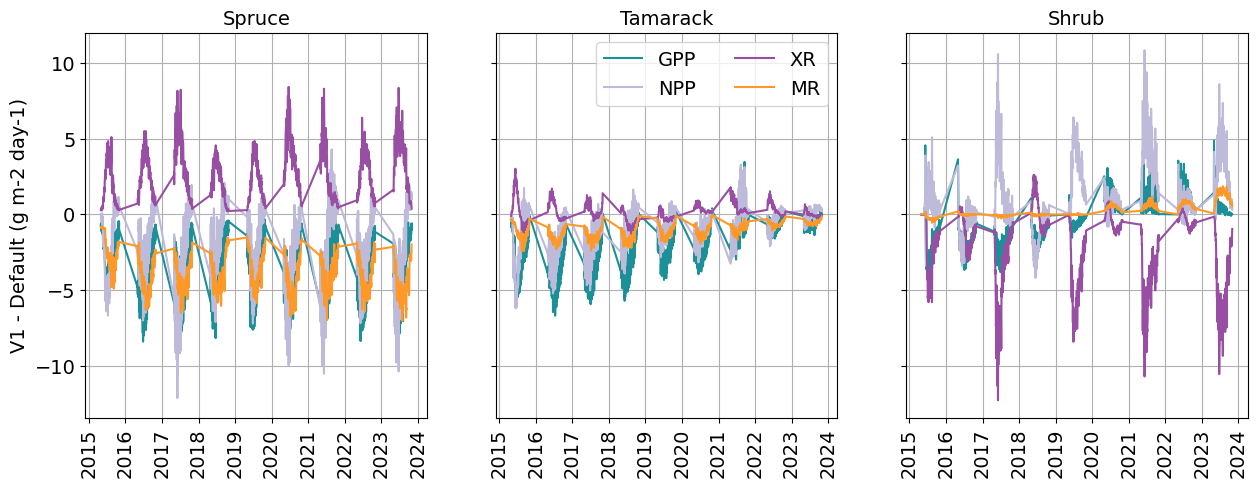

In [7]:
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! Need to find out where this term went
# coz it is different and not part of XR
# xsmrpool_recover

color_list = ['#1c9099', '#bebada', '#984ea3', '#fe9929']

fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = True)
plot = '10'
for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
    ax = axes.flat[i]
    for j, var in enumerate(['GPP', 'NPP', 'XR', 'MR']):
        default = collection_gs[prefix_default].loc[:, (plot, var, pft)] * 86400
        uptake = collection_gs[prefix_uptake].loc[:, (plot, var, pft)] * 86400
        h = ax.plot(default.index, uptake - default, label = var, color = color_list[j])
        ax.grid(True)
        plt.setp(ax.get_xticklabels(), rotation = 90)
        ax.set_title(name)
    if i == 0:
        ax.set_ylabel(f'V1 - Default (g m-2 day-1)')
    if i == 1:
        ax.legend(ncol = 2)

N 2 Spruce
      V1 min froot  V1 min fungi  V1 org fungi
plot                                          
6         0.005987      0.000191      0.016460
20        0.008027      0.000345      0.020207
13        0.012579      0.000273      0.014738
8         0.002953      0.000312      0.020028
17        0.007873      0.000301      0.015645
19        0.001691      0.000151      0.027154
11        0.007005      0.000244      0.025170
4         0.019991      0.000378      0.019007
16        0.015769      0.000318      0.021395
10        0.005683      0.000631      0.027444
N 3 Tamarack
      V1 min froot  V1 min fungi  V1 org fungi
plot                                          
6         0.002887      0.000011      0.017686
20        0.003485      0.000012      0.018437
13        0.002554      0.000006      0.015296
8         0.004203      0.000027      0.017753
17        0.002431      0.000007      0.014252
19        0.004956      0.000042      0.031513
11        0.005761      0.000022    

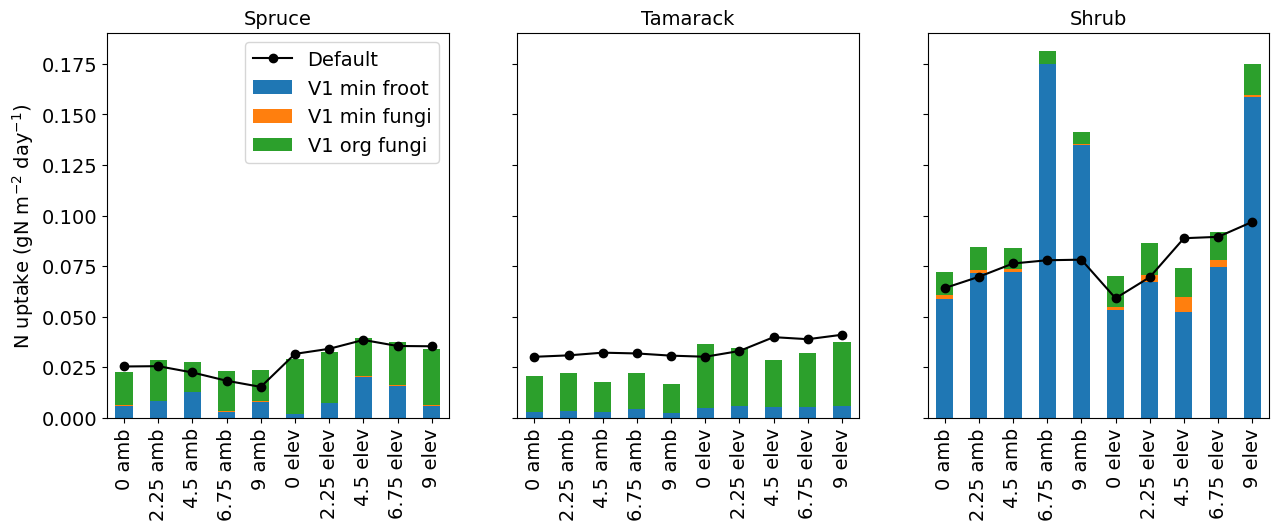

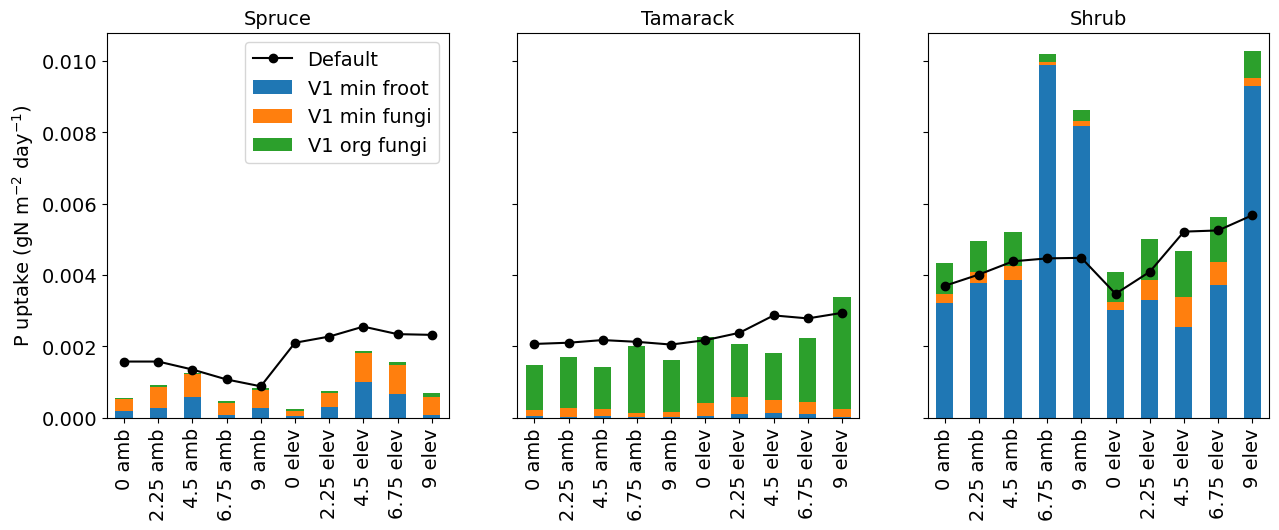

In [14]:
xticklabels = ['0 amb', '2.25 amb','4.5 amb', '6.75 amb', '9 amb', 
               '0 elev', '2.25 elev', '4.5 elev', '6.75 elev', '9 elev']

for nu in ['N','P']:
    fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = True)
    for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
        ax = axes.flat[i]

        prefix = prefix_default
        temp = collection_gs[prefix].mean(axis = 0).unstack().unstack( \
            ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
        froot_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] * 86400
        ax.plot(range(len(froot_min)), froot_min, '-ko', label = 'Default')

        prefix = prefix_uptake
        temp = collection_gs[prefix].mean(axis = 0).unstack().unstack( \
            ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
        froot_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] / \
            temp.loc[:, (pft, f'PLANT_{nu}DEMAND_POT')] * \
            temp.loc[:, (pft, f'FROOT_{nu}DEMAND_POT')]
        fungi_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] / \
            temp.loc[:, (pft, f'PLANT_{nu}DEMAND_POT')] * \
            temp.loc[:, (pft, f'FUNGI_{nu}DEMAND_POT')]
        fungi_som = temp.loc[:, (pft, f'FUNGI_SOM_TO_{nu}POOL')]
        retemp = pd.concat([froot_min, fungi_min, fungi_som], axis = 1) * 86400
        retemp.columns = ['V1 min froot', 'V1 min fungi', 'V1 org fungi']

        #print(nu, pft, name)
        #print(retemp)

        if i == 0:
            retemp.plot(kind='bar', stacked=True, ax = ax)
        else:
            retemp.plot(kind='bar', stacked=True, ax = ax, legend = False)

        if i == 0:
            ax.set_ylabel(f'{nu} uptake ' + '(gN m$^{-2}$ day$^{-1}$)')
            ax.legend()

        ax.set_xticklabels(xticklabels)
        ax.set_xlabel(None)
        ax.set_title(name)

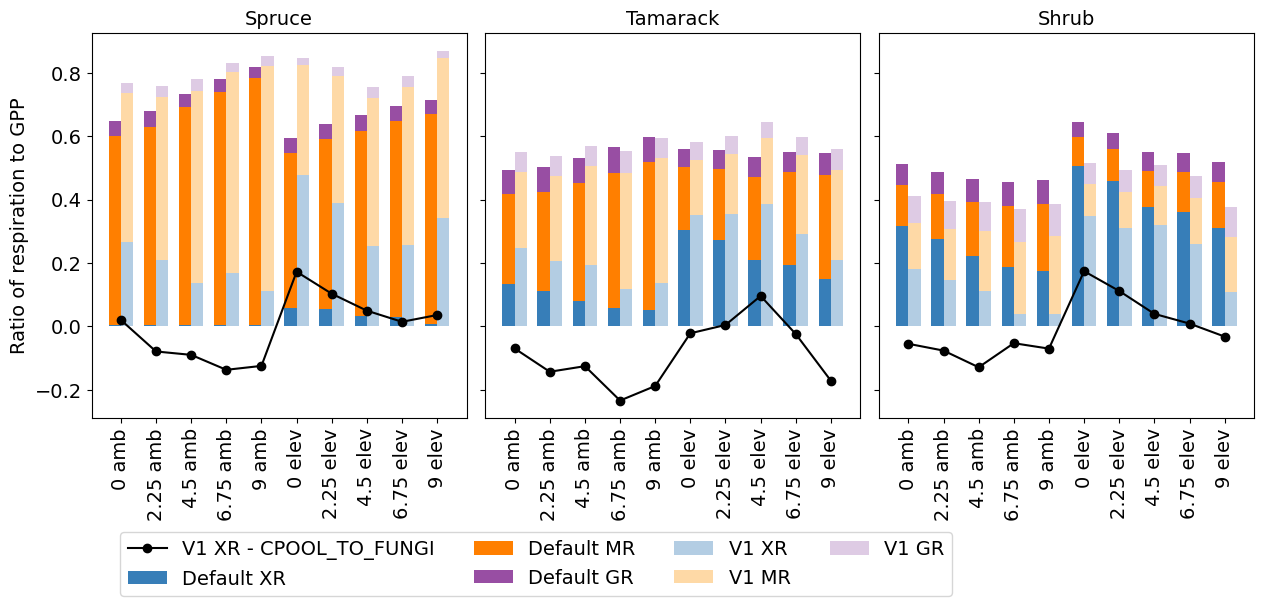

In [9]:
def create_multi_level_stacked_barplot(ax, df):
    """
    Create a stacked bar plot from a DataFrame with two-level columns.
    The first level columns are plotted as separate groups,
    and the second level columns are stacked within each group.
    
    Parameters:
    ax (matplotlib.axes.Axes): The axis to plot on
    df (pandas.DataFrame): The data to plot, with multi-level columns
    """
    # Get the unique values from the first level of the column index
    top_level = df.columns.get_level_values(0).unique()
    
    # Set up the x locations for the groups
    x = np.arange(len(df.index))
    width = 0.35  # Width of each bar group
    color_list = [
        '#377eb8', '#ff7f00', '#984ea3',
        '#b3cde3', '#fed9a6', '#decbe4'
    ]

    for i, group in enumerate(top_level):
        bottom = np.zeros(len(df.index))
        for j,col in enumerate(df[group].columns):
            ax.bar(x + i*width - width/2, df[group][col], width, bottom=bottom, 
                   label=f'{group} {col}', color=color_list[i*3+j])
            bottom += df[group][col]

xticklabels = ['0 amb', '2.25 amb','4.5 amb', '6.75 amb', '9 amb', 
               '0 elev', '2.25 elev', '4.5 elev', '6.75 elev', '9 elev']

fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = True)
fig.subplots_adjust(wspace = 0.05)
for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):

    prefix = prefix_default
    temp = collection_gs[prefix].mean(axis = 0).unstack().unstack( \
        ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
    xr = temp.loc[:, (pft, 'XR')] / temp.loc[:, (pft, 'GPP')]
    mr = temp.loc[:, (pft, 'MR')] / temp.loc[:, (pft, 'GPP')]
    gr = temp.loc[:, (pft, 'GR')] / temp.loc[:, (pft, 'GPP')]
    retemp = pd.concat([xr, mr, gr], axis = 1)
    retemp.columns = ['XR', 'MR', 'GR']

    prefix = prefix_uptake
    temp = collection_gs[prefix].mean(axis = 0).unstack().unstack( \
        ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
    cpool_to_fungi = temp.loc[:, (pft, 'CPOOL_TO_FUNGI')] / temp.loc[:, (pft, 'GPP')]
    xr = temp.loc[:, (pft, 'XR')] / temp.loc[:, (pft, 'GPP')]
    mr = temp.loc[:, (pft, 'MR')] / temp.loc[:, (pft, 'GPP')]
    gr = temp.loc[:, (pft, 'GR')] / temp.loc[:, (pft, 'GPP')]
    retemp2 = pd.concat([xr, mr, gr], axis = 1)
    retemp2.columns = ['XR', 'MR', 'GR']

    retemp3 = pd.concat([retemp, retemp2], axis = 1, keys = ['Default', 'V1'])

    ax = axes.flat[i]
    create_multi_level_stacked_barplot(ax, retemp3)
    ax.plot(np.arange(temp.shape[0]), 
            retemp2['XR'] - cpool_to_fungi, '-o', color = 'k', 
            label = 'V1 XR - CPOOL_TO_FUNGI')

    if i == 0:
        ax.set_ylabel('Ratio of respiration to GPP')
        ax.legend(ncol = 4, bbox_to_anchor=(0.05, -0.27), loc='upper left')

    ax.set_xticks(range(len(xticklabels)))
    ax.set_xticklabels(xticklabels, rotation = 90)
    ax.set_xlabel(None)
    ax.set_title(name)